# FinSmart — FinBot & Sistem Rekomendasi Anggaran

---

## Yang Dikerjakan di Notebook Ini

| # | Tugas  | Checklist |
|---|---|---|
| 1 | Kembangkan FinBot berbasis NLP (Hugging Face) |  Cell 3–6 |
| 2 | Implementasi sistem rekomendasi anggaran personal |  Cell 7–9 |
| 3 | Dokumentasi arsitektur pipeline AI end-to-end |  Cell 10 |
| 4 | Update FastAPI — tambah endpoint FinBot & Rekomendasi |  Cell 11 |

> **Catatan:** Notebook ini dijalankan **setelah** `FinSmart_AI_Engineer.ipynb` selesai dijalankan,
> karena membutuhkan file encoders.pkl, scaler.pkl, dan finsmart_model.keras.

---
## 1️. Install & Import Library

In [1]:
!pip install transformers torch scikit-learn fastapi uvicorn -q

print("Instalasi selesai")

Instalasi selesai


In [2]:
import numpy as np
import pandas as pd
import json
import os
import pickle
import re
from sklearn.metrics.pairwise import cosine_similarity

from transformers import pipeline

print("Semua library berhasil diimport")

Semua library berhasil diimport


---
## 2️. Load Dataset (untuk konteks rekomendasi)

In [3]:
df = pd.read_csv("personal_finance_dataset_8000_extended.csv", sep=";")

print(f"Dataset loaded: {df.shape}")
print(f"Kolom: {list(df.columns)}")
df.head(3)

Dataset loaded: (8000, 15)
Kolom: ['Date', 'Description', 'Amount', 'Category', 'PaymentMethod', 'Location', 'AccountType', 'TransactionType', 'DeviceUsed', 'Currency', 'MerchantType', 'LoyaltyProgram', 'Weekday', 'Month', 'TimeOfDay']


,Date,Description,Amount,Category,PaymentMethod,Location,AccountType,TransactionType,DeviceUsed,Currency,MerchantType,LoyaltyProgram,Weekday,Month,TimeOfDay
0,05/04/2025,Transaction at IRCTC,2066649,Travel,Debit Card,Kolkata,Salary,Debit,Mobile,INR,Service,No,Saturday,April,Night
1,06/12/2025,Transaction at Myntra,191905,Online Shopping,Net Banking,Hyderabad,Salary,Debit,Desktop,INR,Online Store,Yes,Saturday,December,Evening
2,20/06/2025,Transaction at BigBazaar,283768,Grocery,Debit Card,Bangalore,Savings,Debit,Mobile,INR,Retail,No,Friday,June,Evening


---
## 3️. FinBot — Chatbot Keuangan Berbasis NLP (Hugging Face)

> **Penjelasan Arsitektur FinBot:**
>
> FinBot menggunakan pendekatan **Intent Classification + Response Mapping**:
> 1. Input pertanyaan pengguna  **Zero-Shot Classification** (Hugging Face)
> 2. Model mendeteksi intent dari pertanyaan (misal: *tanya_tips*, *tanya_kategori*, dll)
> 3. Sistem memetakan intent  respons yang sesuai
>
> Model yang digunakan: facebook/bart-large-mnli (Zero-Shot Classification)
> — tidak perlu training, langsung bisa classify teks ke label apapun.

In [4]:
print("Loading model Hugging Face (pertama kali butuh beberapa menit)...")

finbot_classifier = pipeline(
    task="zero-shot-classification",
    model="facebook/bart-large-mnli"
)

print("Model FinBot (Hugging Face) berhasil diload!")

Loading model Hugging Face (pertama kali butuh beberapa menit)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Model FinBot (Hugging Face) berhasil diload!


In [5]:
INTENT_LABELS = [
    "tips menabung",
    "cara mengatur anggaran",
    "kategori pengeluaran",
    "investasi untuk pemula",
    "cara mengurangi pengeluaran",
    "target tabungan",
    "rekomendasi keuangan",
    "pengertian literasi keuangan",
]

RESPONSE_DATABASE = {
    "tips menabung": (
        " **Tips Menabung yang Efektif:**\n"
        "1. Terapkan metode **50/30/20** — 50% kebutuhan, 30% keinginan, 20% tabungan.\n"
        "2. Simpan di awal bulan sebelum digunakan (pay yourself first).\n"
        "3. Buat rekening tabungan terpisah dari rekening harian.\n"
        "4. Mulai dari nominal kecil tapi konsisten — Rp 50.000/hari = Rp 1,5 juta/bulan.\n"
        "5. Gunakan fitur **Target Tabungan** di FinSmart untuk pantau progres kamu! "
    ),
    "cara mengatur anggaran": (
        "**Cara Mengatur Anggaran Bulanan:**\n"
        "1. Catat semua pemasukan bulanan kamu terlebih dahulu.\n"
        "2. Bagi pengeluaran ke kategori: Makanan, Transport, Tagihan, Hiburan, dll.\n"
        "3. Tentukan batas maksimal untuk setiap kategori.\n"
        "4. Pantau pengeluaran harian agar tidak melebihi batas.\n"
        "5. FinSmart bisa otomatis mengingatkan kamu saat mendekati batas anggaran! "
    ),
    "kategori pengeluaran": (
        "**Kategori Pengeluaran di FinSmart:**\n"
        "FinSmart mengklasifikasikan transaksimu ke 10 kategori:\n"
        "1. Food (Makanan)\n"
        "2. Grocery (Belanja Kebutuhan)\n"
        "3. Transport (Transportasi)\n"
        "4. Entertainment (Hiburan)\n"
        "5. Healthcare (Kesehatan)\n"
        "6. Electronics (Elektronik)\n"
        "7. Online Shopping\n"
        "8. Travel (Perjalanan)\n"
        "9. Clothing (Pakaian)\n"
        "10. Bills (Tagihan)\n\n"
        "Kategori ditentukan otomatis oleh AI saat kamu input transaksi!"
    ),
    "investasi untuk pemula": (
        "**Panduan Investasi untuk Pemula:**\n"
        "Sebelum investasi, pastikan kamu sudah:\n"
        "Punya dana darurat (3–6x pengeluaran bulanan)\n"
        "Tidak punya hutang konsumtif\n"
        "Tabungan rutin sudah berjalan\n\n"
        "Pilihan investasi untuk pemula:\n"
        "• **Reksa Dana Pasar Uang** — risiko rendah, cocok untuk pemula\n"
        "• **Deposito** — aman, bunga pasti\n"
        "• **Obligasi Negara (ORI/SBR)** — dijamin pemerintah\n\n"
        "Cek fitur **Kesiapan Investasi** di FinSmart untuk analisis profil keuanganmu! "
    ),
    "cara mengurangi pengeluaran": (
        " **Tips Mengurangi Pengeluaran:**\n"
        "1. Identifikasi kategori pengeluaran terbesar kamu dari dashboard FinSmart.\n"
        "2. Bedakan **kebutuhan** (harus) vs **keinginan** (bisa ditunda).\n"
        "3. Kurangi frekuensi makan di luar — masak sendiri bisa hemat 60%.\n"
        "4. Manfaatkan promo & cashback saat belanja online.\n"
        "5. Batalkan langganan yang jarang dipakai (streaming, app, dll).\n"
        "6. Pantau tren pengeluaranmu dengan grafik FinSmart! "
    ),
    "target tabungan": (
        " **Cara Menetapkan Target Tabungan:**\n"
        "1. Tentukan tujuan spesifik: liburan, DP rumah, dana darurat, dll.\n"
        "2. Hitung nominal yang dibutuhkan dan deadline-nya.\n"
        "3. Bagi dengan jumlah bulan → ini target tabungan bulanan kamu.\n"
        "4. Set target di fitur **Sistem Anggaran** FinSmart.\n"
        "5. FinSmart akan notifikasi jika kamu on-track atau perlu penyesuaian! "
    ),
    "rekomendasi keuangan": (
        " **Rekomendasi Keuangan Personal:**\n"
        "Berdasarkan data keuanganmu, FinSmart memberikan rekomendasi:\n"
        "• Analisis pola pengeluaran bulanan\n"
        "• Kategori mana yang paling banyak menguras anggaran\n"
        "• Prediksi pengeluaran bulan depan\n"
        "• Rekomendasi batas anggaran per kategori\n\n"
        "Masuk ke menu **Analisis & Rekomendasi AI** untuk melihat insight personalmu! "
    ),
    "pengertian literasi keuangan": (
        " **Apa itu Literasi Keuangan?**\n"
        "Literasi keuangan adalah kemampuan memahami dan menggunakan\n"
        "berbagai konsep keuangan secara efektif, meliputi:\n"
        "• Mengelola pendapatan & pengeluaran\n"
        "• Merencanakan tabungan & investasi\n"
        "• Memahami produk keuangan (kredit, asuransi, investasi)\n"
        "• Membuat keputusan keuangan yang bijak\n\n"
        "Data OJK 2024: literasi keuangan generasi muda Indonesia masih di bawah 50%.\n"
        "FinSmart hadir untuk membantu meningkatkan literasi keuanganmu! "
    ),
}

RESPONSE_DEFAULT = (
    " Maaf, saya belum bisa menjawab pertanyaan itu secara spesifik.\n"
    "Kamu bisa tanya saya tentang:\n"
    "• Tips menabung\n"
    "• Cara mengatur anggaran\n"
    "• Kategori pengeluaran\n"
    "• Investasi untuk pemula\n"
    "• Cara mengurangi pengeluaran\n"
    "• Target tabungan\n"
)

print(f"Database FinBot siap: {len(RESPONSE_DATABASE)} intent terdaftar")

Database FinBot siap: 8 intent terdaftar


---
## 4️. Kelas FinBot

In [6]:
class FinBot:
    """
    FinBot — Chatbot Keuangan FinSmart.

    Menggunakan Hugging Face Zero-Shot Classification
    untuk mendeteksi intent dari pertanyaan pengguna,
    lalu memetakan ke respons yang sesuai.

    Model: facebook/bart-large-mnli
    """

    def __init__(self, classifier, intent_labels, response_db, threshold=0.30):
        self.classifier   = classifier
        self.intent_labels = intent_labels
        self.response_db  = response_db
        self.threshold    = threshold
        self.chat_history = []

    def detect_intent(self, pertanyaan: str) -> tuple:
        """Deteksi intent dari pertanyaan menggunakan Zero-Shot Classification."""
        result = self.classifier(
            pertanyaan,
            candidate_labels=self.intent_labels,
            hypothesis_template="Pertanyaan ini tentang {}."
        )
        top_intent = result['labels'][0]
        top_score  = result['scores'][0]
        return top_intent, top_score

    def chat(self, pertanyaan: str) -> dict:
        """
        Proses satu pertanyaan dari pengguna.

        Returns:
            dict: intent, confidence, respons
        """
        pertanyaan = pertanyaan.strip()
        if not pertanyaan:
            return {"error": "Pertanyaan tidak boleh kosong."}

        intent, confidence = self.detect_intent(pertanyaan)

        if confidence >= self.threshold:
            respons = self.response_db.get(intent, RESPONSE_DEFAULT)
        else:
            respons = RESPONSE_DEFAULT
            intent  = "tidak_terdeteksi"

        entry = {
            "pertanyaan" : pertanyaan,
            "intent"     : intent,
            "confidence" : round(confidence * 100, 2),
            "respons"    : respons,
        }
        self.chat_history.append(entry)

        return entry

    def tampilkan_respons(self, result: dict):
        """Tampilkan hasil chat dengan format yang rapi."""
        print("=" * 60)
        print(f"Pertanyaan : {result['pertanyaan']}")
        print(f"Intent     : {result['intent']} ({result['confidence']}%)")
        print("-" * 60)
        print(f"FinBot     :\n{result['respons']}")
        print("=" * 60)


finbot = FinBot(
    classifier   = finbot_classifier,
    intent_labels = INTENT_LABELS,
    response_db  = RESPONSE_DATABASE,
    threshold    = 0.30
)

print("FinBot berhasil diinisialisasi!")

FinBot berhasil diinisialisasi!


---
## 5️. Uji FinBot — Contoh Percakapan

In [7]:
pertanyaan_uji = [
    "Gimana cara biar bisa nabung lebih banyak tiap bulan?",
    "Aku mau mulai investasi tapi masih pemula, harus mulai dari mana?",
    "Pengeluaran makanku terlalu besar, gimana cara nguranginnya?",
    "Apa itu kategori pengeluaran di FinSmart?",
    "Bantu aku bikin target tabungan untuk liburan",
]

for pertanyaan in pertanyaan_uji:
    result = finbot.chat(pertanyaan)
    finbot.tampilkan_respons(result)
    print()

Pertanyaan : Gimana cara biar bisa nabung lebih banyak tiap bulan?
Intent     : tidak_terdeteksi (15.88%)
------------------------------------------------------------
FinBot     :
 Maaf, saya belum bisa menjawab pertanyaan itu secara spesifik.
Kamu bisa tanya saya tentang:
• Tips menabung
• Cara mengatur anggaran
• Kategori pengeluaran
• Investasi untuk pemula
• Cara mengurangi pengeluaran
• Target tabungan


Pertanyaan : Aku mau mulai investasi tapi masih pemula, harus mulai dari mana?
Intent     : tidak_terdeteksi (23.45%)
------------------------------------------------------------
FinBot     :
 Maaf, saya belum bisa menjawab pertanyaan itu secara spesifik.
Kamu bisa tanya saya tentang:
• Tips menabung
• Cara mengatur anggaran
• Kategori pengeluaran
• Investasi untuk pemula
• Cara mengurangi pengeluaran
• Target tabungan


Pertanyaan : Pengeluaran makanku terlalu besar, gimana cara nguranginnya?
Intent     : cara mengurangi pengeluaran (36.48%)
--------------------------------------

In [8]:
with open("finbot_chat_history.json", "w", encoding="utf-8") as f:
    json.dump(finbot.chat_history, f, ensure_ascii=False, indent=2)

print(f"Chat history disimpan → 'finbot_chat_history.json'")
print(f"   Total percakapan: {len(finbot.chat_history)}")

Chat history disimpan → 'finbot_chat_history.json'
   Total percakapan: 5


---
## 6️. Sistem Rekomendasi Anggaran Personal

> **Penjelasan:**  
> Sistem ini menganalisis profil keuangan pengguna (income, pengeluaran per kategori, target tabungan)  
> lalu memberikan:
> - Rekomendasi batas anggaran per kategori (metode 50/30/20)
> - Deteksi kategori yang over-budget
> - Analisis kesiapan investasi
> - Rekomendasi instrumen investasi sesuai profil

In [9]:
class RekomendasiAnggaran:
    """
    Sistem rekomendasi anggaran personal FinSmart.

    Berdasarkan profil keuangan pengguna, sistem ini menghasilkan:
    1. Rekomendasi anggaran per kategori (metode 50/30/20)
    2. Deteksi kategori yang melebihi batas wajar
    3. Skor kesiapan investasi (0-100)
    4. Rekomendasi instrumen investasi
    """

    # Bobot ideal pengeluaran per kategori (% dari income)
    # Berdasarkan standar literasi keuangan OJK
    BOBOT_IDEAL = {
        "Food"           : 0.15,   # 15% dari income
        "Grocery"        : 0.10,
        "Transport"      : 0.10,
        "Bills"          : 0.10,
        "Healthcare"     : 0.05,
        "Entertainment"  : 0.05,
        "Online Shopping": 0.05,
        "Clothing"       : 0.05,
        "Electronics"    : 0.05,
        "Travel"         : 0.05,
    }

    # Instrumen investasi berdasarkan profil risiko
    INSTRUMEN_INVESTASI = {
        "konservatif": [
            "Tabungan berjangka / Deposito",
            "Obligasi Negara Ritel (ORI / SBR)",
            "Reksa Dana Pasar Uang",
        ],
        "moderat": [
            "Reksa Dana Pasar Uang",
            "Reksa Dana Pendapatan Tetap",
            "Obligasi Negara Ritel (ORI / SBR)",
            "P2P Lending terpercaya (OJK)",
        ],
        "agresif": [
            "Reksa Dana Saham",
            "Saham blue-chip (LQ45)",
            "ETF / Index Fund",
            "REITs (properti digital)",
        ],
    }

    def __init__(self, income_bulanan: float, tabungan_bulanan: float,
                 pengeluaran_per_kategori: dict, usia: int = 25):
        """
        Args:
            income_bulanan         : Total pemasukan per bulan (Rp)
            tabungan_bulanan       : Jumlah yang berhasil ditabung per bulan (Rp)
            pengeluaran_per_kategori: dict {kategori: total_pengeluaran_bulan_ini}
            usia                   : Usia pengguna (untuk profil risiko)
        """
        self.income          = income_bulanan
        self.tabungan        = tabungan_bulanan
        self.pengeluaran     = pengeluaran_per_kategori
        self.usia            = usia
        self.total_pengeluaran = sum(pengeluaran_per_kategori.values())
        self.rasio_tabungan  = tabungan_bulanan / income_bulanan if income_bulanan > 0 else 0

    def hitung_rekomendasi_anggaran(self) -> dict:
        """Hitung batas anggaran ideal per kategori."""
        rekomendasi = {}
        for kategori, bobot in self.BOBOT_IDEAL.items():
            batas_ideal    = self.income * bobot
            aktual         = self.pengeluaran.get(kategori, 0)
            selisih        = aktual - batas_ideal
            status         = "Over" if selisih > 0 else "Aman"
            rekomendasi[kategori] = {
                "batas_ideal"  : round(batas_ideal),
                "aktual"       : round(aktual),
                "selisih"      : round(selisih),
                "status"       : status,
                "persen_income": round((aktual / self.income) * 100, 1) if self.income > 0 else 0,
            }
        return rekomendasi

    def hitung_skor_investasi(self) -> dict:
        """
        Hitung skor kesiapan investasi (0-100).
        Berdasarkan 4 faktor:
        - Rasio tabungan (40 poin)
        - Sisa income setelah pengeluaran (30 poin)
        - Konsistensi pengeluaran (20 poin)
        - Usia (10 poin)
        """
        skor = 0
        detail = {}

        # 1. Skor rasio tabungan (max 40)
        # Ideal: menabung ≥ 20% income
        skor_tabungan = min(40, int(self.rasio_tabungan / 0.20 * 40))
        skor += skor_tabungan
        detail["skor_tabungan"] = skor_tabungan

        # 2. Skor sisa income (max 30)
        sisa_income = self.income - self.total_pengeluaran - self.tabungan
        rasio_sisa  = max(0, sisa_income / self.income) if self.income > 0 else 0
        skor_sisa   = min(30, int(rasio_sisa * 100))
        skor += skor_sisa
        detail["skor_sisa_income"] = skor_sisa

        # 3. Skor efisiensi pengeluaran (max 20)
        rasio_pengeluaran = self.total_pengeluaran / self.income if self.income > 0 else 1
        if rasio_pengeluaran <= 0.50:
            skor_efisiensi = 20
        elif rasio_pengeluaran <= 0.70:
            skor_efisiensi = 10
        else:
            skor_efisiensi = 0
        skor += skor_efisiensi
        detail["skor_efisiensi"] = skor_efisiensi

        # 4. Skor usia (max 10) — semakin muda semakin baik (waktu investasi panjang)
        if self.usia <= 25:
            skor_usia = 10
        elif self.usia <= 35:
            skor_usia = 7
        else:
            skor_usia = 5
        skor += skor_usia
        detail["skor_usia"] = skor_usia

        # Label kesiapan
        if skor >= 70:
            label = "Siap Investasi"
            profil_risiko = "moderat" if skor < 85 else "agresif"
        elif skor >= 45:
            label = "Hampir Siap — Perlu Sedikit Perbaikan"
            profil_risiko = "konservatif"
        else:
            label = "Belum Siap — Fokus Perbaiki Keuangan Dulu"
            profil_risiko = "konservatif"

        return {
            "skor"         : skor,
            "label"        : label,
            "profil_risiko": profil_risiko,
            "detail_skor"  : detail,
        }

    def generate_rekomendasi(self) -> dict:
        """Generate laporan rekomendasi lengkap."""
        anggaran  = self.hitung_rekomendasi_anggaran()
        investasi = self.hitung_skor_investasi()

        # Kategori yang over budget
        over_budget = [
            k for k, v in anggaran.items()
            if v["status"] == "Over"
        ]

        # Instrumen investasi sesuai profil
        instrumen = self.INSTRUMEN_INVESTASI.get(
            investasi["profil_risiko"], []
        )

        return {
            "ringkasan": {
                "income_bulanan"     : self.income,
                "total_pengeluaran"  : self.total_pengeluaran,
                "tabungan_bulanan"   : self.tabungan,
                "rasio_tabungan_pct" : round(self.rasio_tabungan * 100, 1),
            },
            "rekomendasi_anggaran" : anggaran,
            "kategori_over_budget" : over_budget,
            "kesiapan_investasi"   : investasi,
            "rekomendasi_instrumen": instrumen,
        }

    def tampilkan_laporan(self):
        """Tampilkan laporan rekomendasi dengan format rapi."""
        hasil = self.generate_rekomendasi()

        print("=" * 65)
        print("LAPORAN REKOMENDASI ANGGARAN — FinSmart")
        print("=" * 65)

        r = hasil["ringkasan"]
        print(f"\nRINGKASAN KEUANGAN:")
        print(f"   Income Bulanan    : Rp {r['income_bulanan']:>12,.0f}")
        print(f"   Total Pengeluaran : Rp {r['total_pengeluaran']:>12,.0f}")
        print(f"   Tabungan Bulanan  : Rp {r['tabungan_bulanan']:>12,.0f}")
        print(f"   Rasio Tabungan    : {r['rasio_tabungan_pct']}%")

        print(f"\nANGGARAN PER KATEGORI:")
        print(f"   {'Kategori':<18} {'Ideal':>12} {'Aktual':>12} {'Selisih':>12} Status")
        print(f"   {'-'*18} {'-'*12} {'-'*12} {'-'*12} {'-'*12}")
        for kat, v in hasil["rekomendasi_anggaran"].items():
            print(
                f"   {kat:<18} "
                f"Rp {v['batas_ideal']:>9,.0f} "
                f"Rp {v['aktual']:>9,.0f} "
                f"Rp {v['selisih']:>+9,.0f} "
                f"{v['status']}"
            )

        over = hasil["kategori_over_budget"]
        if over:
            print(f"\n KATEGORI OVER BUDGET: {', '.join(over)}")
            print("   → Pertimbangkan untuk mengurangi pengeluaran di kategori ini.")

        inv = hasil["kesiapan_investasi"]
        print(f"\n KESIAPAN INVESTASI:")
        print(f"   Skor           : {inv['skor']}/100")
        print(f"   Status         : {inv['label']}")
        print(f"   Profil Risiko  : {inv['profil_risiko'].capitalize()}")

        print(f"\n REKOMENDASI INSTRUMEN INVESTASI:")
        for instrumen in hasil["rekomendasi_instrumen"]:
            print(f"   {instrumen}")

        print("=" * 65)
        return hasil


print("Kelas RekomendasiAnggaran berhasil didefinisikan!")

Kelas RekomendasiAnggaran berhasil didefinisikan!


---
## 7️. Uji Sistem Rekomendasi Anggaran

In [10]:
print("\n" + "="*65)
print("UJI KASUS 1: Pengguna A (Karyawan, 24 tahun)")
print("="*65)

rekomendasi_1 = RekomendasiAnggaran(
    income_bulanan=5_000_000,
    tabungan_bulanan=1_000_000,
    pengeluaran_per_kategori={
        "Food"           : 800_000,
        "Grocery"        : 400_000,
        "Transport"      : 500_000,
        "Bills"          : 300_000,
        "Entertainment"  : 400_000,
        "Online Shopping": 300_000,
        "Healthcare"     : 100_000,
        "Clothing"       : 200_000,
        "Electronics"    : 0,
        "Travel"         : 0,
    },
    usia=24
)
hasil_1 = rekomendasi_1.tampilkan_laporan()


UJI KASUS 1: Pengguna A (Karyawan, 24 tahun)
LAPORAN REKOMENDASI ANGGARAN — FinSmart

RINGKASAN KEUANGAN:
   Income Bulanan    : Rp    5,000,000
   Total Pengeluaran : Rp    3,000,000
   Tabungan Bulanan  : Rp    1,000,000
   Rasio Tabungan    : 20.0%

ANGGARAN PER KATEGORI:
   Kategori                  Ideal       Aktual      Selisih Status
   ------------------ ------------ ------------ ------------ ------------
   Food               Rp   750,000 Rp   800,000 Rp   +50,000 Over
   Grocery            Rp   500,000 Rp   400,000 Rp  -100,000 Aman
   Transport          Rp   500,000 Rp   500,000 Rp        +0 Aman
   Bills              Rp   500,000 Rp   300,000 Rp  -200,000 Aman
   Healthcare         Rp   250,000 Rp   100,000 Rp  -150,000 Aman
   Entertainment      Rp   250,000 Rp   400,000 Rp  +150,000 Over
   Online Shopping    Rp   250,000 Rp   300,000 Rp   +50,000 Over
   Clothing           Rp   250,000 Rp   200,000 Rp   -50,000 Aman
   Electronics        Rp   250,000 Rp         0 Rp  -

In [11]:
print("\n" + "="*65)
print("UJI KASUS 2: Pengguna B (Mahasiswa, 21 tahun)")
print("="*65)

rekomendasi_2 = RekomendasiAnggaran(
    income_bulanan=2_000_000,
    tabungan_bulanan=100_000,
    pengeluaran_per_kategori={
        "Food"           : 700_000,
        "Grocery"        : 200_000,
        "Transport"      : 300_000,
        "Bills"          : 200_000,
        "Entertainment"  : 300_000,
        "Online Shopping": 250_000,
        "Healthcare"     : 50_000,
        "Clothing"       : 150_000,
        "Electronics"    : 0,
        "Travel"         : 0,
    },
    usia=21
)
hasil_2 = rekomendasi_2.tampilkan_laporan()


UJI KASUS 2: Pengguna B (Mahasiswa, 21 tahun)
LAPORAN REKOMENDASI ANGGARAN — FinSmart

RINGKASAN KEUANGAN:
   Income Bulanan    : Rp    2,000,000
   Total Pengeluaran : Rp    2,150,000
   Tabungan Bulanan  : Rp      100,000
   Rasio Tabungan    : 5.0%

ANGGARAN PER KATEGORI:
   Kategori                  Ideal       Aktual      Selisih Status
   ------------------ ------------ ------------ ------------ ------------
   Food               Rp   300,000 Rp   700,000 Rp  +400,000 Over
   Grocery            Rp   200,000 Rp   200,000 Rp        +0 Aman
   Transport          Rp   200,000 Rp   300,000 Rp  +100,000 Over
   Bills              Rp   200,000 Rp   200,000 Rp        +0 Aman
   Healthcare         Rp   100,000 Rp    50,000 Rp   -50,000 Aman
   Entertainment      Rp   100,000 Rp   300,000 Rp  +200,000 Over
   Online Shopping    Rp   100,000 Rp   250,000 Rp  +150,000 Over
   Clothing           Rp   100,000 Rp   150,000 Rp   +50,000 Over
   Electronics        Rp   100,000 Rp         0 Rp  -

In [12]:
# Simpan contoh hasil rekomendasi ke JSON (untuk dokumentasi & API)
with open("contoh_rekomendasi.json", "w", encoding="utf-8") as f:
    json.dump({
        "pengguna_A": hasil_1,
        "pengguna_B": hasil_2,
    }, f, ensure_ascii=False, indent=2)

print("Contoh rekomendasi disimpan 'contoh_rekomendasi.json'")

Contoh rekomendasi disimpan 'contoh_rekomendasi.json'


---
## 8️. Dokumentasi Arsitektur Pipeline AI End-to-End

In [13]:
arsitektur = {
    "nama_proyek"   : "FinSmart AI Pipeline",
    "versi"         : "1.0.0",
    "ai_engineer"   : "Muhammad Syaiful",
    "capstone_id"   : "CC26-PSU407",

    "komponen": {

        "1_klasifikasi_pengeluaran": {
            "deskripsi"  : "Model Deep Learning untuk mengklasifikasikan kategori pengeluaran",
            "model"      : "TensorFlow Functional API — Dense Neural Network",
            "input"      : "Amount, PaymentMethod, Location, AccountType, TransactionType, "
                           "DeviceUsed, MerchantType, LoyaltyProgram, Weekday, Month, TimeOfDay",
            "output"     : "10 kelas kategori pengeluaran",
            "custom"     : "FinSmartCallback (Custom Callback — Main Quest)",
            "format_model": "finsmart_model.keras (TensorFlow SavedModel)",
            "endpoint_api": "POST /classify",
        },

        "2_finbot_chatbot": {
            "deskripsi"  : "Chatbot keuangan berbasis NLP untuk menjawab pertanyaan pengguna",
            "model"      : "Hugging Face — facebook/bart-large-mnli (Zero-Shot Classification)",
            "teknik"     : "Zero-Shot Classification + Intent-Response Mapping",
            "input"      : "Pertanyaan pengguna dalam bahasa Indonesia",
            "output"     : "Respons keuangan berdasarkan intent yang terdeteksi",
            "jumlah_intent": len(INTENT_LABELS),
            "endpoint_api": "POST /finbot/chat",
        },

        "3_rekomendasi_anggaran": {
            "deskripsi"  : "Sistem rekomendasi anggaran personal berbasis profil keuangan",
            "metode"     : "Rule-Based Scoring + Threshold Analysis",
            "input"      : "income_bulanan, tabungan_bulanan, pengeluaran_per_kategori, usia",
            "output"     : "Rekomendasi anggaran per kategori + skor kesiapan investasi",
            "acuan"      : "Metode 50/30/20 + Standar Literasi Keuangan OJK",
            "endpoint_api": "POST /rekomendasi",
        },

        "4_api_serving": {
            "deskripsi"  : "REST API untuk menyajikan semua model AI ke front-end",
            "framework"  : "FastAPI + Uvicorn",
            "endpoints"  : [
                "GET  /              — health check",
                "POST /classify      — klasifikasi pengeluaran",
                "POST /finbot/chat   — chatbot FinBot",
                "POST /rekomendasi   — rekomendasi anggaran",
                "GET  /model-info    — info model",
                "GET  /valid-values  — nilai valid tiap fitur",
                "GET  /docs          — Swagger UI",
            ],
            "integrasi"  : "Dipanggil oleh back-end Node.js/Express via HTTP",
        },
    },

    "alur_data": [
        "1. Pengguna input transaksi di front-end (React.js)",
        "2. Front-end kirim request ke back-end (Node.js/Express)",
        "3. Back-end forward ke AI Service (FastAPI) via HTTP POST",
        "4. FastAPI load model → preprocessing → inference",
        "5. Hasil prediksi dikembalikan ke back-end → front-end",
        "6. Dashboard menampilkan kategori + insight kepada pengguna",
    ],

    "file_artifacts": [
        "finsmart_model.keras     — Model klasifikasi TF",
        "encoders.pkl             — Label encoders",
        "scaler.pkl               — StandardScaler",
        "model_metadata.json      — Metadata & performa model",
        "training_log.json        — Log training per epoch",
        "finbot_chat_history.json — Contoh percakapan FinBot",
        "contoh_rekomendasi.json  — Contoh output rekomendasi",
        "main.py                  — FastAPI server",
    ],
}

with open("arsitektur_ai.json", "w", encoding="utf-8") as f:
    json.dump(arsitektur, f, ensure_ascii=False, indent=2)

print("Dokumentasi arsitektur disimpan → 'arsitektur_ai.json'")
print()
print("ALUR PIPELINE AI END-TO-END:")
for step in arsitektur["alur_data"]:
    print(f"   {step}")
print()
print("KOMPONEN AI:")
for nama, detail in arsitektur["komponen"].items():
    print(f"   [{nama}] {detail['deskripsi']}")
    print(f"            Model/Metode : {detail.get('model', detail.get('metode', detail.get('framework', '-')))}")
    print(f"            Endpoint API : {detail.get('endpoint_api', detail.get('endpoints', ['-'])[0])}")
    print()

Dokumentasi arsitektur disimpan → 'arsitektur_ai.json'

ALUR PIPELINE AI END-TO-END:
   1. Pengguna input transaksi di front-end (React.js)
   2. Front-end kirim request ke back-end (Node.js/Express)
   3. Back-end forward ke AI Service (FastAPI) via HTTP POST
   4. FastAPI load model → preprocessing → inference
   5. Hasil prediksi dikembalikan ke back-end → front-end
   6. Dashboard menampilkan kategori + insight kepada pengguna

KOMPONEN AI:
   [1_klasifikasi_pengeluaran] Model Deep Learning untuk mengklasifikasikan kategori pengeluaran
            Model/Metode : TensorFlow Functional API — Dense Neural Network
            Endpoint API : POST /classify

   [2_finbot_chatbot] Chatbot keuangan berbasis NLP untuk menjawab pertanyaan pengguna
            Model/Metode : Hugging Face — facebook/bart-large-mnli (Zero-Shot Classification)
            Endpoint API : POST /finbot/chat

   [3_rekomendasi_anggaran] Sistem rekomendasi anggaran personal berbasis profil keuangan
            Model/

---
## 9️. Update FastAPI — Tambah Endpoint FinBot & Rekomendasi

In [14]:
main_complete = '''
"""
FinSmart AI Service — FastAPI LENGKAP
Coding Camp 2026 | CC26-PSU407 | AI Engineer: Muhammad Syaiful

Endpoints:
  GET  /              — health check
  POST /classify      — klasifikasi kategori pengeluaran
  POST /finbot/chat   — chatbot keuangan FinBot
  POST /rekomendasi   — rekomendasi anggaran personal
  GET  /model-info    — info model
  GET  /valid-values  — nilai valid tiap fitur
  GET  /docs          — Swagger UI

Jalankan: uvicorn main_complete:app --reload --port 8000
"""

import numpy as np
import pickle
import json
from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from typing import Optional
from tensorflow import keras
from transformers import pipeline as hf_pipeline

# INISIALISASI APP
# ============================================================
app = FastAPI(
    title="FinSmart AI Service",
    description="API lengkap untuk klasifikasi pengeluaran, FinBot, dan rekomendasi anggaran",
    version="1.0.0"
)
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"], allow_methods=["*"], allow_headers=["*"]
)

# LOAD SEMUA MODEL & ARTIFACTS
# ============================================================
print("Loading model klasifikasi...")
model = keras.models.load_model("finsmart_model.keras")
with open("encoders.pkl", "rb") as f: encoders = pickle.load(f)
with open("scaler.pkl",   "rb") as f: scaler   = pickle.load(f)
with open("model_metadata.json") as f: metadata = json.load(f)

print("Loading FinBot (Hugging Face)...")
finbot_clf = hf_pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)
print("Semua model berhasil diload!")

FITUR_KAT = [
    "PaymentMethod", "Location", "AccountType",
    "TransactionType", "DeviceUsed", "MerchantType",
    "LoyaltyProgram", "Weekday", "Month", "TimeOfDay"
]

INTENT_LABELS = [
    "tips menabung", "cara mengatur anggaran", "kategori pengeluaran",
    "investasi untuk pemula", "cara mengurangi pengeluaran",
    "target tabungan", "rekomendasi keuangan", "pengertian literasi keuangan",
]

RESPONSE_DB = {
    "tips menabung": "Terapkan metode 50/30/20: 50% kebutuhan, 30% keinginan, 20% tabungan. Simpan di awal bulan sebelum digunakan!",
    "cara mengatur anggaran": "Catat semua pemasukan, bagi ke kategori, tentukan batas, dan pantau setiap hari. Gunakan fitur Anggaran di FinSmart!",
    "kategori pengeluaran": "FinSmart mengklasifikasikan ke 10 kategori: Food, Grocery, Transport, Entertainment, Healthcare, Electronics, Online Shopping, Travel, Clothing, Bills.",
    "investasi untuk pemula": "Pastikan punya dana darurat dulu. Lalu mulai dari Reksa Dana Pasar Uang atau Deposito. Cek fitur Kesiapan Investasi di FinSmart!",
    "cara mengurangi pengeluaran": "Identifikasi kategori terbesar dari dashboard, bedakan kebutuhan vs keinginan, dan pantau tren pengeluaranmu!",
    "target tabungan": "Tentukan tujuan spesifik, hitung nominal & deadline, bagi per bulan, lalu set target di FinSmart. Kami akan notifikasi progresmu!",
    "rekomendasi keuangan": "Lihat menu Analisis & Rekomendasi AI di FinSmart untuk insight personal berdasarkan data keuanganmu.",
    "pengertian literasi keuangan": "Kemampuan memahami & menggunakan konsep keuangan: mengelola income, menabung, investasi, dan membuat keputusan finansial yang bijak.",
}
RESPONSE_DEFAULT = "Maaf, saya belum bisa menjawab itu. Coba tanya tentang tips menabung, anggaran, investasi, atau kategori pengeluaran."

BOBOT_IDEAL = {
    "Food": 0.15, "Grocery": 0.10, "Transport": 0.10, "Bills": 0.10,
    "Healthcare": 0.05, "Entertainment": 0.05, "Online Shopping": 0.05,
    "Clothing": 0.05, "Electronics": 0.05, "Travel": 0.05,
}

INSTRUMEN = {
    "konservatif": ["Tabungan berjangka / Deposito", "Obligasi Negara (ORI/SBR)", "Reksa Dana Pasar Uang"],
    "moderat"    : ["Reksa Dana Pendapatan Tetap", "ORI/SBR", "P2P Lending OJK"],
    "agresif"    : ["Reksa Dana Saham", "Saham blue-chip (LQ45)", "ETF / Index Fund"],
}

# SCHEMA REQUEST
# ============================================================
class TransaksiInput(BaseModel):
    Amount: float
    PaymentMethod: str
    Location: str
    AccountType: str
    TransactionType: str
    DeviceUsed: str
    MerchantType: str
    LoyaltyProgram: str
    Weekday: str
    Month: str
    TimeOfDay: str

class ChatInput(BaseModel):
    pertanyaan: str

class RekomendasiInput(BaseModel):
    income_bulanan: float
    tabungan_bulanan: float
    usia: int = 25
    pengeluaran: dict  # {kategori: jumlah}

# ENDPOINTS
# ============================================================
@app.get("/", tags=["Health"])
def root():
    return {"status": "ok", "service": "FinSmart AI Service", "version": "1.0.0"}

@app.post("/classify", tags=["Klasifikasi"])
def classify(transaksi: TransaksiInput):
    data = transaksi.dict()
    row = {}
    for col in FITUR_KAT:
        le = encoders[col]
        if data[col] not in le.classes_:
            raise HTTPException(422, f"Nilai tidak valid: {col}={data[col]}")
        row[col] = le.transform([data[col]])[0]
    row["Amount"] = scaler.transform([[data["Amount"]]])[0][0]
    X = np.array([[row[f] for f in FITUR_KAT + ["Amount"]]])
    proba = model.predict(X, verbose=0)[0]
    idx = int(np.argmax(proba))
    kategori = encoders["Category"].inverse_transform([idx])[0]
    semua = encoders["Category"].classes_
    top3 = dict(sorted(
        {k: round(float(p), 4) for k, p in zip(semua, proba)}.items(),
        key=lambda x: x[1], reverse=True
    )[:3])
    return {"kategori": kategori, "confidence": round(float(proba[idx])*100, 2), "top3_prob": top3}

@app.post("/finbot/chat", tags=["FinBot"])
def finbot_chat(body: ChatInput):
    if not body.pertanyaan.strip():
        raise HTTPException(422, "Pertanyaan tidak boleh kosong.")
    result = finbot_clf(body.pertanyaan, candidate_labels=INTENT_LABELS,
                        hypothesis_template="Pertanyaan ini tentang {}.")
    intent = result["labels"][0]
    confidence = result["scores"][0]
    respons = RESPONSE_DB.get(intent, RESPONSE_DEFAULT) if confidence >= 0.30 else RESPONSE_DEFAULT
    return {"intent": intent, "confidence": round(confidence*100, 2), "respons": respons}

@app.post("/rekomendasi", tags=["Rekomendasi"])
def rekomendasi_anggaran(body: RekomendasiInput):
    income = body.income_bulanan
    anggaran = {}
    for kat, bobot in BOBOT_IDEAL.items():
        ideal  = income * bobot
        aktual = body.pengeluaran.get(kat, 0)
        anggaran[kat] = {
            "batas_ideal": round(ideal),
            "aktual": round(aktual),
            "selisih": round(aktual - ideal),
            "status": "Over" if aktual > ideal else "Aman",
        }
    rasio_tab = body.tabungan_bulanan / income if income > 0 else 0
    total_exp = sum(body.pengeluaran.values())
    skor = min(40, int(rasio_tab/0.20*40))
    sisa = max(0, (income - total_exp - body.tabungan_bulanan)/income)
    skor += min(30, int(sisa*100))
    ratio_exp = total_exp/income if income>0 else 1
    skor += 20 if ratio_exp<=0.50 else (10 if ratio_exp<=0.70 else 0)
    skor += 10 if body.usia<=25 else (7 if body.usia<=35 else 5)
    profil = "agresif" if skor>=85 else ("moderat" if skor>=70 else "konservatif")
    label  = ("Siap Investasi" if skor>=70 else
               "Hampir Siap" if skor>=45 else "Belum Siap")
    return {
        "rekomendasi_anggaran": anggaran,
        "kesiapan_investasi": {"skor": skor, "label": label, "profil_risiko": profil},
        "rekomendasi_instrumen": INSTRUMEN.get(profil, []),
        "over_budget": [k for k, v in anggaran.items() if v["status"]=="Over"],
    }

@app.get("/model-info", tags=["Info"])
def model_info(): return metadata

@app.get("/valid-values", tags=["Info"])
def valid_values():
    return {col: list(encoders[col].classes_) for col in FITUR_KAT}
'''

with open("main_complete.py", "w", encoding="utf-8") as f:
    f.write(main_complete.strip())

print("FastAPI lengkap berhasil digenerate → 'main_complete.py'")
print()
print("Cara menjalankan:")
print("   uvicorn main_complete:app --reload --port 8000")
print()
print("Semua endpoint:")
print("   GET  /              → health check")
print("   POST /classify      → klasifikasi pengeluaran")
print("   POST /finbot/chat   → chatbot FinBot")
print("   POST /rekomendasi   → rekomendasi anggaran + kesiapan investasi")
print("   GET  /model-info    → info model")
print("   GET  /valid-values  → nilai valid tiap fitur")
print("   GET  /docs          → Swagger UI otomatis")

FastAPI lengkap berhasil digenerate → 'main_complete.py'

Cara menjalankan:
   uvicorn main_complete:app --reload --port 8000

Semua endpoint:
   GET  /              → health check
   POST /classify      → klasifikasi pengeluaran
   POST /finbot/chat   → chatbot FinBot
   POST /rekomendasi   → rekomendasi anggaran + kesiapan investasi
   GET  /model-info    → info model
   GET  /valid-values  → nilai valid tiap fitur
   GET  /docs          → Swagger UI otomatis


---
## Ringkasan Akhir — Semua Tugas AI Engineer

In [15]:
print("=" * 65)
print("RINGKASAN TUGAS AI ENGINEER — FinSmart CC26-PSU407")
print("=" * 65)

print("\nMAIN QUEST (dari notebook FinSmart_AI_Engineer.ipynb):")
print("  1. Model TensorFlow Functional API      ")
print("  2. Custom Callback (FinSmartCallback)   ")
print("  3. Model disimpan format .keras         ")
print("  4. Kode inference model                 ")

print("\nSIDE QUEST:")
print("  1. REST API FastAPI (main_complete.py)  ")
print("  2. Target akurasi ≥ 85%                 (setelah training)")

print("\nTUGAS PROJECT PLAN (Job Desk AI Engineer):")
print("  1. Arsitektur pipeline AI end-to-end      arsitektur_ai.json")
print("  2. FinBot NLP (Hugging Face)              notebook ini")
print("  3. Optimasi inferensi real-time           FastAPI + model caching")
print("  4. Rekomendasi anggaran personal          notebook ini")
print("  5. Integrasi AI dengan back-end FastAPI   main_complete.py")
print("  6. Evaluasi teknis & dokumentasi          arsitektur_ai.json")

print("\nFILE YANG DIHASILKAN (notebook ini):")
files = [
    "finbot_chat_history.json",
    "contoh_rekomendasi.json",
    "arsitektur_ai.json",
    "main_complete.py",
]
for f in files:
    ada = "" if os.path.exists(f) else " (generate cell di atas)"
    print(f"  {ada} {f}")

print("\n=" * 65)

RINGKASAN TUGAS AI ENGINEER — FinSmart CC26-PSU407

MAIN QUEST (dari notebook FinSmart_AI_Engineer.ipynb):
  1. Model TensorFlow Functional API      
  2. Custom Callback (FinSmartCallback)   
  3. Model disimpan format .keras         
  4. Kode inference model                 

SIDE QUEST:
  1. REST API FastAPI (main_complete.py)  
  2. Target akurasi ≥ 85%                 (setelah training)

TUGAS PROJECT PLAN (Job Desk AI Engineer):
  1. Arsitektur pipeline AI end-to-end      arsitektur_ai.json
  2. FinBot NLP (Hugging Face)              notebook ini
  3. Optimasi inferensi real-time           FastAPI + model caching
  4. Rekomendasi anggaran personal          notebook ini
  5. Integrasi AI dengan back-end FastAPI   main_complete.py
  6. Evaluasi teknis & dokumentasi          arsitektur_ai.json

FILE YANG DIHASILKAN (notebook ini):
   finbot_chat_history.json
   contoh_rekomendasi.json
   arsitektur_ai.json
   main_complete.py

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=

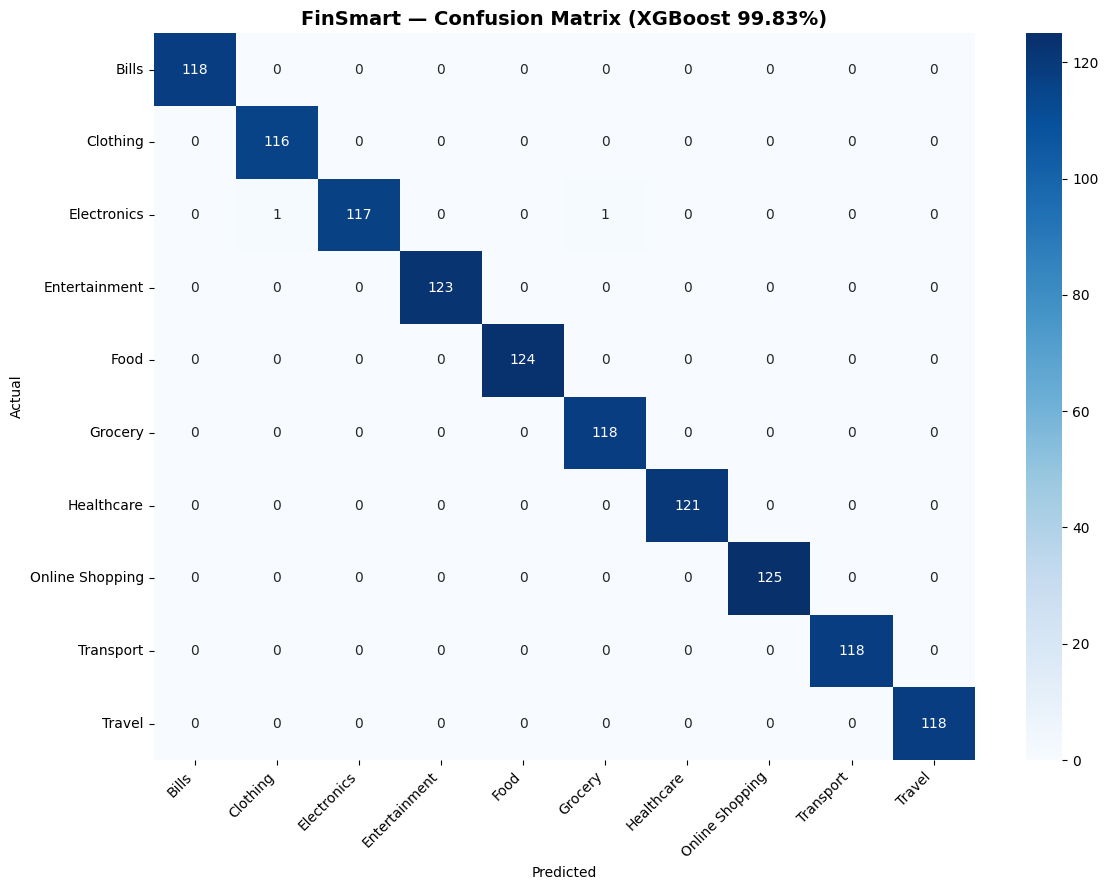

confusion_matrix.png berhasil dibuat!


In [16]:
# GENERATE ULANG confusion_matrix.png
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load ulang dataset & proses seperti Notebook 1
df_cm = pd.read_csv("personal_finance_dataset_8000_extended.csv", sep=";")
df_cm['MerchantName'] = df_cm['Description'].str.replace('Transaction at ', '', regex=False).str.strip()

FITUR_KAT = ['PaymentMethod', 'Location', 'AccountType', 'TransactionType',
             'DeviceUsed', 'MerchantType', 'LoyaltyProgram', 'Weekday',
             'Month', 'TimeOfDay', 'MerchantName']
FITUR_NUM = ['Amount']

with open("encoders.pkl", "rb") as f:
    encoders = pickle.load(f)
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

df_proc = df_cm[FITUR_KAT + FITUR_NUM + ['Category']].copy()
for col in FITUR_KAT:
    df_proc[col] = encoders[col].transform(df_proc[col])
df_proc[FITUR_NUM] = scaler.transform(df_proc[FITUR_NUM])
df_proc['Category'] = encoders['Category'].transform(df_proc['Category'])

X = df_proc[FITUR_KAT + FITUR_NUM].values
y = df_proc['Category'].values
_, X_tmp, _, y_tmp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
_, X_te, _, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp)

# Load XGBoost & predict
xgb_model = joblib.load("xgb_model.pkl")
y_pred = xgb_model.predict(X_te)

# Plot confusion matrix
cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoders['Category'].classes_,
            yticklabels=encoders['Category'].classes_)
plt.title('FinSmart — Confusion Matrix (XGBoost 99.83%)', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("confusion_matrix.png berhasil dibuat!")